In [3]:
# =========================================================
# 0) Gerekli importlar
# =========================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Torch version: 2.10.0+cu128
CUDA available: True
Device: cuda


In [4]:
# =========================================================
# 1) BASE_DIR AYARI
# processed klasörünü nereye koyduğuna göre bunu seç
# =========================================================

# Seçenek A: Google Drive içine yüklediysen
BASE_DIR = "/content/drive/MyDrive/processed"

# Seçenek B: Colab oturumuna doğrudan yüklediysen bunu aç, üsttekini kapat
# BASE_DIR = "/content/processed"

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("BASE_DIR:", BASE_DIR)
print("İçerik:", os.listdir(BASE_DIR))

BASE_DIR exists: True
BASE_DIR: /content/drive/MyDrive/processed
İçerik: ['nsclc_index.csv', 'train_patients.csv', 'val_patients.csv', 'slice_index_positive_only.csv', 'masks', 'images', 'notebooks', 'last_model.pt', 'best_model_simple_unet.pt']


In [5]:
# =========================================================
# 2) CSV'LERİ OKU
# =========================================================
train_df = pd.read_csv(f"{BASE_DIR}/train_patients.csv")
val_df = pd.read_csv(f"{BASE_DIR}/val_patients.csv")
slice_df = pd.read_csv(f"{BASE_DIR}/slice_index_positive_only.csv")

print("Train hasta:", len(train_df))
print("Val hasta:", len(val_df))
print("Toplam slice:", len(slice_df))
print(slice_df["split"].value_counts())
slice_df.head()

Train hasta: 84
Val hasta: 22
Toplam slice: 1989
split
train    1627
val       362
Name: count, dtype: int64


,patient_id,image_path,mask_path,slice_idx,split
0,LUNG1-002,processed\images\LUNG1-002.npy,processed\masks\LUNG1-002.npy,28,train
1,LUNG1-002,processed\images\LUNG1-002.npy,processed\masks\LUNG1-002.npy,29,train
2,LUNG1-002,processed\images\LUNG1-002.npy,processed\masks\LUNG1-002.npy,30,train
3,LUNG1-002,processed\images\LUNG1-002.npy,processed\masks\LUNG1-002.npy,31,train
4,LUNG1-002,processed\images\LUNG1-002.npy,processed\masks\LUNG1-002.npy,32,train


In [6]:
# =========================================================
# 3) PATH DÜZELTME
# CSV içindeki Windows path'leri Colab path'ine çevir
# =========================================================
def fix_image_path(p: str) -> str:
    fname = os.path.basename(str(p).replace("\\", "/"))
    return f"{BASE_DIR}/images/{fname}"

def fix_mask_path(p: str) -> str:
    fname = os.path.basename(str(p).replace("\\", "/"))
    return f"{BASE_DIR}/masks/{fname}"

slice_df["image_path"] = slice_df["image_path"].apply(fix_image_path)
slice_df["mask_path"] = slice_df["mask_path"].apply(fix_mask_path)

# Kontrol
print(slice_df[["image_path", "mask_path"]].head())
print("İlk image exists:", os.path.exists(slice_df.iloc[0]["image_path"]))
print("İlk mask exists :", os.path.exists(slice_df.iloc[0]["mask_path"]))

                                          image_path  \
0  /content/drive/MyDrive/processed/images/LUNG1-...   
1  /content/drive/MyDrive/processed/images/LUNG1-...   
2  /content/drive/MyDrive/processed/images/LUNG1-...   
3  /content/drive/MyDrive/processed/images/LUNG1-...   
4  /content/drive/MyDrive/processed/images/LUNG1-...   

                                           mask_path  
0  /content/drive/MyDrive/processed/masks/LUNG1-0...  
1  /content/drive/MyDrive/processed/masks/LUNG1-0...  
2  /content/drive/MyDrive/processed/masks/LUNG1-0...  
3  /content/drive/MyDrive/processed/masks/LUNG1-0...  
4  /content/drive/MyDrive/processed/masks/LUNG1-0...  
İlk image exists: True
İlk mask exists : True


In [7]:
# =========================================================
# 4) TRAIN / VAL SLICE DATAFRAME
# =========================================================
train_slice_df = slice_df[slice_df["split"] == "train"].reset_index(drop=True)
val_slice_df = slice_df[slice_df["split"] == "val"].reset_index(drop=True)

print("Train slice:", len(train_slice_df))
print("Val slice:", len(val_slice_df))

Train slice: 1627
Val slice: 362


In [8]:
# =========================================================
# 5) DATASET CLASS
# =========================================================
class LungSliceDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        mask_path = row["mask_path"]
        slice_idx = int(row["slice_idx"])

        # Güvenlik kontrolü
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image not found: {image_path}")
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        img = np.load(image_path, mmap_mode="r")
        mask = np.load(mask_path, mmap_mode="r")

        img_slice = img[slice_idx].astype(np.float32)
        mask_slice = mask[slice_idx].astype(np.float32)

        # HU clipping + normalization
        img_slice = np.clip(img_slice, -1000, 400)
        img_slice = (img_slice + 1000.0) / 1400.0

        # Channel dimension ekle: (1, H, W)
        img_slice = np.expand_dims(img_slice, axis=0)
        mask_slice = np.expand_dims(mask_slice, axis=0)

        return (
            torch.tensor(img_slice, dtype=torch.float32),
            torch.tensor(mask_slice, dtype=torch.float32),
        )

In [9]:
# =========================================================
# 6) DATASET VE DATALOADER
# CPU kullanacaksan num_workers=0 daha güvenli
# =========================================================
train_dataset = LungSliceDataset(train_slice_df)
val_dataset = LungSliceDataset(val_slice_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("Train batch sayısı:", len(train_loader))
print("Val batch sayısı:", len(val_loader))

Train batch sayısı: 204
Val batch sayısı: 46


In [10]:
# =========================================================
# 7) İLK BATCH KONTROL
# =========================================================
x, y = next(iter(train_loader))

print("Image batch shape:", x.shape)
print("Mask batch shape :", y.shape)
print("Image min/max    :", x.min().item(), x.max().item())
print("Mask unique      :", torch.unique(y))

Image batch shape: torch.Size([8, 1, 512, 512])
Mask batch shape : torch.Size([8, 1, 512, 512])
Image min/max    : 0.0 1.0
Mask unique      : tensor([0., 1.])


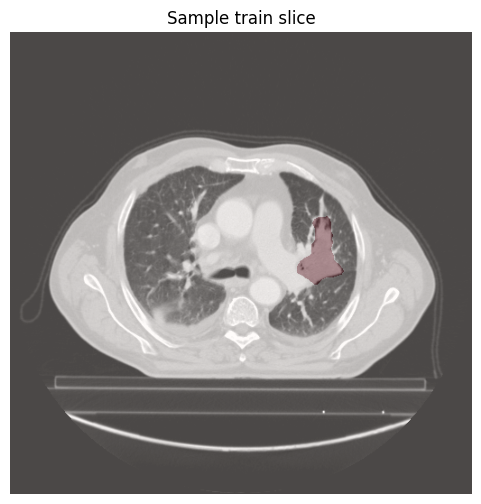

In [11]:
# =========================================================
# 8) GÖRSEL KONTROL
# =========================================================
img = x[0, 0].cpu().numpy()
msk = y[0, 0].cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(msk, cmap="Reds", alpha=0.3)
plt.title("Sample train slice")
plt.axis("off")
plt.show()

In [12]:
# =========================================================
# 9) BASİT U-NET BENZERİ MODEL
# =========================================================
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.out_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.out_conv(d1)
        return out

In [13]:
# =========================================================
# 10) LOSS VE METRİK
# =========================================================
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(-1)
    targets = targets.view(-1)

    intersection = (probs * targets).sum()
    dice = (2.0 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)
    return 1.0 - dice

def combined_loss(logits, targets):
    return 0.5 * bce_loss(logits, targets) + 0.5 * dice_loss(logits, targets)

In [14]:
# =========================================================
# 11) MODEL KURULUMU
# =========================================================
model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model.__class__.__name__)

SimpleUNet


In [15]:
# =========================================================
# 12) EĞİTİM LOOP
# CPU için 2 epoch ile başla
# =========================================================
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = combined_loss(logits, y)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

num_epochs = 2
best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f"{BASE_DIR}/best_model_simple_unet.pt")
        print("Best model saved.")

torch.save(model.state_dict(), f"{BASE_DIR}/last_model.pt")
print("Model kaydedildi!")

model.load_state_dict(torch.load(f"{BASE_DIR}/last_model.pt", map_location=device))


KeyboardInterrupt: 

In [ ]:
import os

model_path = f"{BASE_DIR}/best_model_simple_unet.pt"

print("Dosya var mı:", os.path.exists(model_path))
print("Path:", model_path)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

x_val, y_val = next(iter(val_loader))
x_val = x_val.to(device)

with torch.no_grad():
    logits = model(x_val)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

num_show = min(4, x_val.shape[0])

fig, axes = plt.subplots(num_show, 3, figsize=(12, 4 * num_show))

if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_show):
    img = x_val[i, 0].cpu().numpy()
    gt = y_val[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Image {i}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img, cmap="gray")
    axes[i, 1].imshow(gt, cmap="Reds", alpha=0.3)
    axes[i, 1].set_title(f"Ground Truth {i}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img, cmap="gray")
    axes[i, 2].imshow(pred, cmap="Blues", alpha=0.3)
    axes[i, 2].set_title(f"Prediction {i}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def dice_score_batch(pred, target, smooth=1e-6):
    pred = pred.view(pred.shape[0], -1)
    target = target.view(target.shape[0], -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)
    return dice.mean().item()

model.eval()

with torch.no_grad():
    x_val, y_val = next(iter(val_loader))
    x_val = x_val.to(device)
    y_val_gpu = y_val.to(device)

    logits = model(x_val)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    dice = dice_score_batch(preds, y_val_gpu)
    print("Validation batch Dice:", dice)

In [ ]:
idx = 0

img = x_val[idx, 0].cpu().numpy()
gt = y_val[idx, 0].cpu().numpy()
pred = preds[idx, 0].cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(gt, cmap="gray")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

axes[2].imshow(pred, cmap="gray")
axes[2].set_title("Predicted Mask")
axes[2].axis("off")

axes[3].imshow(img, cmap="gray")
axes[3].imshow(gt, cmap="Reds", alpha=0.25)
axes[3].imshow(pred, cmap="Blues", alpha=0.25)
axes[3].set_title("GT + Pred Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [17]:
import torch
print(torch.cuda.is_available())

True


In [16]:
# =========================================================
# 1) IMPORTLAR
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Torch version: 2.10.0+cu128
CUDA available: True
Device: cuda


In [18]:
# =========================================================
# 2) BASE_DIR
# Drive'a yüklediysen bunu kullan
# =========================================================
BASE_DIR = "/content/drive/MyDrive/processed"

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("İçerik:", os.listdir(BASE_DIR))

BASE_DIR exists: True
İçerik: ['nsclc_index.csv', 'train_patients.csv', 'val_patients.csv', 'slice_index_positive_only.csv', 'masks', 'images', 'notebooks', 'last_model.pt', 'best_model_simple_unet.pt']


In [19]:
# =========================================================
# 3) CSV YÜKLE + PATH FIX
# =========================================================
slice_df = pd.read_csv(f"{BASE_DIR}/slice_index_positive_only.csv")

def fix_image_path(p):
    fname = os.path.basename(str(p).replace("\\", "/"))
    return f"{BASE_DIR}/images/{fname}"

def fix_mask_path(p):
    fname = os.path.basename(str(p).replace("\\", "/"))
    return f"{BASE_DIR}/masks/{fname}"

slice_df["image_path"] = slice_df["image_path"].apply(fix_image_path)
slice_df["mask_path"] = slice_df["mask_path"].apply(fix_mask_path)

train_df = slice_df[slice_df["split"] == "train"].reset_index(drop=True)
val_df   = slice_df[slice_df["split"] == "val"].reset_index(drop=True)

print("Train slice:", len(train_df))
print("Val slice:", len(val_df))
print(train_df.head(2))
print("İlk image var mı:", os.path.exists(train_df.iloc[0]["image_path"]))
print("İlk mask var mı :", os.path.exists(train_df.iloc[0]["mask_path"]))

Train slice: 1627
Val slice: 362
  patient_id                                         image_path  \
0  LUNG1-002  /content/drive/MyDrive/processed/images/LUNG1-...   
1  LUNG1-002  /content/drive/MyDrive/processed/images/LUNG1-...   

                                           mask_path  slice_idx  split  
0  /content/drive/MyDrive/processed/masks/LUNG1-0...         28  train  
1  /content/drive/MyDrive/processed/masks/LUNG1-0...         29  train  
İlk image var mı: True
İlk mask var mı : True


In [20]:
# =========================================================
# 4) DATASET
# =========================================================
class LungSliceDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = np.load(row["image_path"], mmap_mode="r")
        mask = np.load(row["mask_path"], mmap_mode="r")

        slice_idx = int(row["slice_idx"])

        img_slice = img[slice_idx].astype(np.float32)
        mask_slice = mask[slice_idx].astype(np.float32)

        # HU clipping + normalization
        img_slice = np.clip(img_slice, -1000, 400)
        img_slice = (img_slice + 1000.0) / 1400.0

        # channel dim ekle
        img_slice = np.expand_dims(img_slice, axis=0)
        mask_slice = np.expand_dims(mask_slice, axis=0)

        return (
            torch.tensor(img_slice, dtype=torch.float32),
            torch.tensor(mask_slice, dtype=torch.float32),
        )

In [21]:
# =========================================================
# 5) DATALOADER
# CPU için num_workers=0 daha güvenli
# =========================================================
train_dataset = LungSliceDataset(train_df)
val_dataset   = LungSliceDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print("Train batch sayısı:", len(train_loader))
print("Val batch sayısı:", len(val_loader))

Train batch sayısı: 204
Val batch sayısı: 46


In [22]:
# =========================================================
# 7) LOSS FONKSİYONLARI
# combined_loss = BCE + Dice
# =========================================================
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.shape[0], -1)
    targets = targets.view(targets.shape[0], -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (probs.sum(dim=1) + targets.sum(dim=1) + smooth)

    return 1.0 - dice.mean()

def combined_loss(logits, targets):
    return 0.5 * bce_loss(logits, targets) + 0.5 * dice_loss(logits, targets)

In [23]:
# =========================================================
# 8) TRAIN / VAL EPOCH FONKSİYONU
# =========================================================
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = combined_loss(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

In [24]:
# =========================================================
# 9) MODELİ KUR
# =========================================================
model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model.__class__.__name__)

SimpleUNet


In [25]:
# =========================================================
# 10) TRAINING
# epoch = 10
# =========================================================
num_epochs = 10
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f"{BASE_DIR}/best_model_simple_unet.pt")
        print("Best model saved.")

# son modeli de ayrıca kaydet
torch.save(model.state_dict(), f"{BASE_DIR}/last_model.pt")
print("Last model saved.")

Epoch 1/10 | Train Loss: 0.5240 | Val Loss: 0.4871
Best model saved.
Epoch 2/10 | Train Loss: 0.4675 | Val Loss: 0.4646
Best model saved.
Epoch 3/10 | Train Loss: 0.4196 | Val Loss: 0.3757
Best model saved.
Epoch 4/10 | Train Loss: 0.3578 | Val Loss: 0.3400
Best model saved.
Epoch 5/10 | Train Loss: 0.3388 | Val Loss: 0.3452
Epoch 6/10 | Train Loss: 0.3211 | Val Loss: 0.3152
Best model saved.
Epoch 7/10 | Train Loss: 0.3071 | Val Loss: 0.3266
Epoch 8/10 | Train Loss: 0.3064 | Val Loss: 0.3268
Epoch 9/10 | Train Loss: 0.2929 | Val Loss: 0.3039
Best model saved.
Epoch 10/10 | Train Loss: 0.2868 | Val Loss: 0.3194
Last model saved.


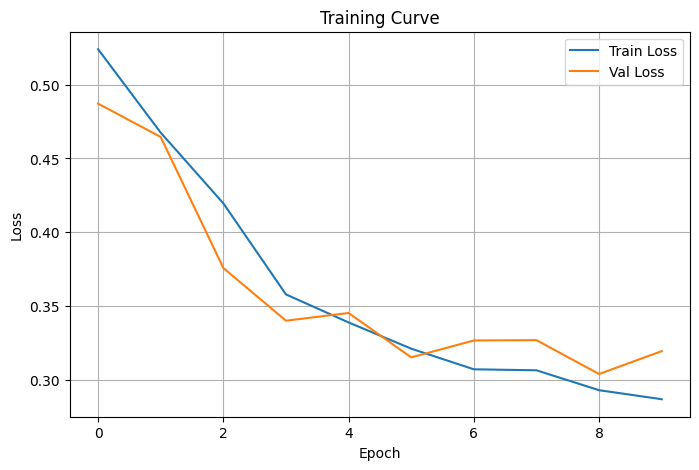

In [26]:
# =========================================================
# 11) LOSS GRAFİĞİ
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# =========================================================
# 12) MODELİ YÜKLE
# =========================================================
model_path = f"{BASE_DIR}/best_model_simple_unet.pt"
print("Dosya var mı:", os.path.exists(model_path))
print("Path:", model_path)

model = SimpleUNet().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Model başarıyla yüklendi.")

Dosya var mı: True
Path: /content/drive/MyDrive/processed/best_model_simple_unet.pt
Model başarıyla yüklendi.


In [31]:
# =========================================================
# 13) DICE SCORE
# =========================================================
def dice_score_batch(pred, target, smooth=1e-6):
    pred = pred.view(pred.shape[0], -1)
    target = target.view(target.shape[0], -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)
    return dice.mean().item()

In [29]:
# =========================================================
# 14) VAL BATCH ÜZERİNDE TAHMİN
# threshold = 0.2 ile deniyoruz
# =========================================================
x_val, y_val = next(iter(val_loader))
x_val_gpu = x_val.to(device)
y_val_gpu = y_val.to(device)

with torch.no_grad():
    logits = model(x_val_gpu)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.2).float()

print("Prob min/max:", probs.min().item(), probs.max().item())

dice = dice_score_batch(preds, y_val_gpu)
print("Validation batch Dice:", dice)

Prob min/max: 3.649943055568605e-16 0.999998927116394
Validation batch Dice: 0.42084771394729614


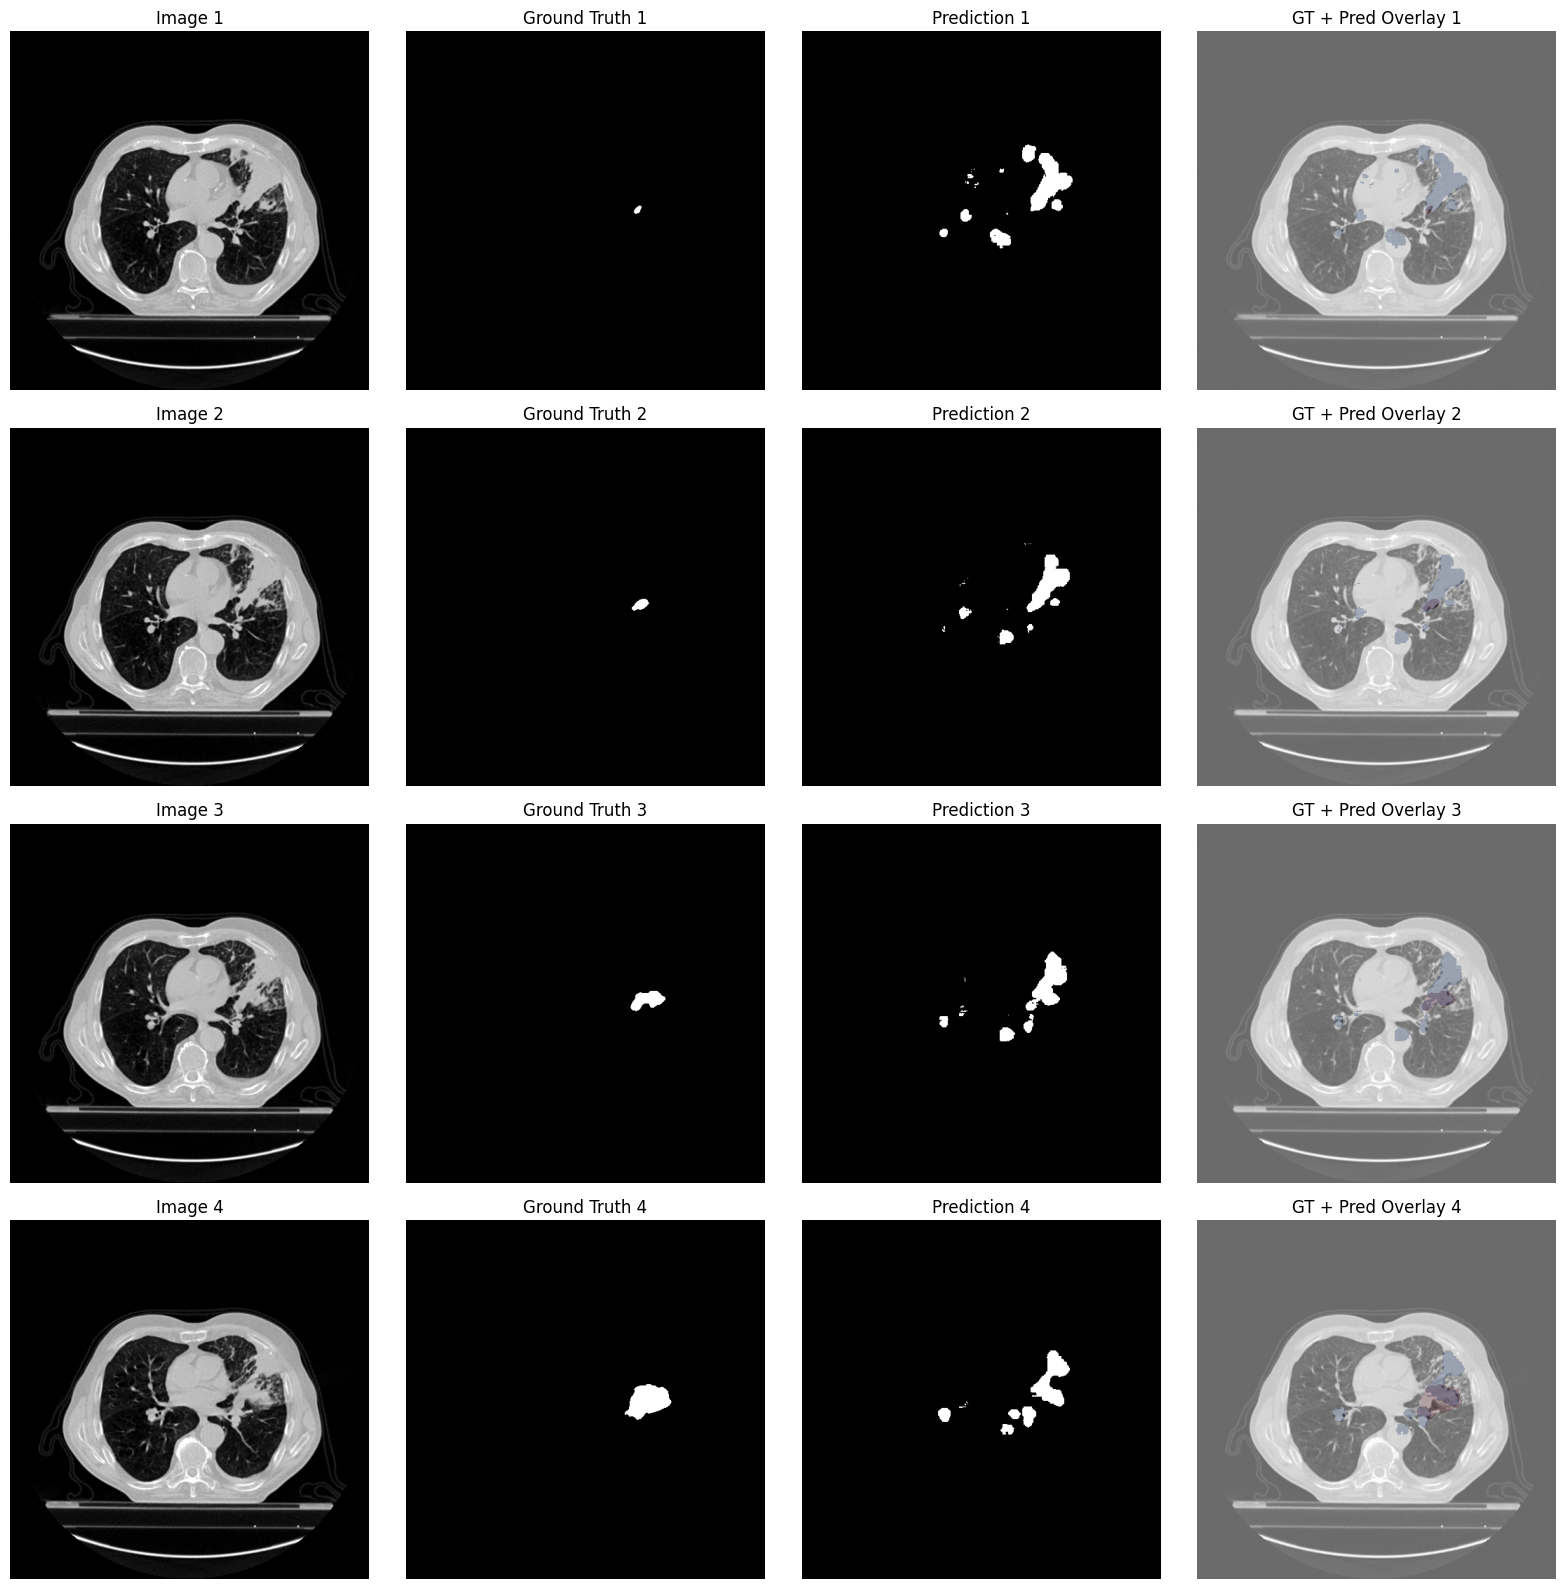

In [30]:
# =========================================================
# 15) BİRKAÇ ÖRNEĞİ GÖRSELLEŞTİR
# =========================================================
num_show = min(4, x_val.shape[0])

fig, axes = plt.subplots(num_show, 4, figsize=(16, 4 * num_show))

if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_show):
    img = x_val[i, 0].cpu().numpy()
    gt = y_val[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt, cmap="gray")
    axes[i, 1].set_title(f"Ground Truth {i+1}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred, cmap="gray")
    axes[i, 2].set_title(f"Prediction {i+1}")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(img, cmap="gray")
    axes[i, 3].imshow(gt, cmap="Reds", alpha=0.25)
    axes[i, 3].imshow(pred, cmap="Blues", alpha=0.25)
    axes[i, 3].set_title(f"GT + Pred Overlay {i+1}")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/processed"  # kendi path'ine göre kontrol et

slice_df = pd.read_csv(f"{BASE_DIR}/slice_index_positive_only.csv")

def fix_image_path(p):
    fname = os.path.basename(str(p).replace("\\", "/"))
    return f"{BASE_DIR}/images/{fname}"

def fix_mask_path(p):
    fname = os.path.basename(str(p).replace("\\", "/"))
    return f"{BASE_DIR}/masks/{fname}"

slice_df["image_path"] = slice_df["image_path"].apply(fix_image_path)
slice_df["mask_path"] = slice_df["mask_path"].apply(fix_mask_path)

train_slice_df = slice_df[slice_df["split"] == "train"].reset_index(drop=True)
val_slice_df = slice_df[slice_df["split"] == "val"].reset_index(drop=True)

print("Train slice sayısı:", len(train_slice_df))
print("Val slice sayısı:", len(val_slice_df))
train_slice_df.head()

Train slice sayısı: 1627
Val slice sayısı: 362


,patient_id,image_path,mask_path,slice_idx,split
0,LUNG1-002,/content/drive/MyDrive/processed/images/LUNG1-...,/content/drive/MyDrive/processed/masks/LUNG1-0...,28,train
1,LUNG1-002,/content/drive/MyDrive/processed/images/LUNG1-...,/content/drive/MyDrive/processed/masks/LUNG1-0...,29,train
2,LUNG1-002,/content/drive/MyDrive/processed/images/LUNG1-...,/content/drive/MyDrive/processed/masks/LUNG1-0...,30,train
3,LUNG1-002,/content/drive/MyDrive/processed/images/LUNG1-...,/content/drive/MyDrive/processed/masks/LUNG1-0...,31,train
4,LUNG1-002,/content/drive/MyDrive/processed/images/LUNG1-...,/content/drive/MyDrive/processed/masks/LUNG1-0...,32,train


In [6]:
print(train_slice_df.iloc[0]["image_path"])
print(train_slice_df.iloc[0]["mask_path"])

print("Image exists:", os.path.exists(train_slice_df.iloc[0]["image_path"]))
print("Mask exists :", os.path.exists(train_slice_df.iloc[0]["mask_path"]))

/content/drive/MyDrive/processed/images/LUNG1-002.npy
/content/drive/MyDrive/processed/masks/LUNG1-002.npy
Image exists: True
Mask exists : True


In [7]:
import numpy as np
import torch
from torch.utils.data import Dataset

class LungSliceDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = np.load(row["image_path"], mmap_mode="r")
        msk = np.load(row["mask_path"], mmap_mode="r")

        slice_idx = int(row["slice_idx"])

        img = img[slice_idx].astype(np.float32)
        msk = msk[slice_idx].astype(np.float32)

        # basit normalization
        img = np.clip(img, -1000, 400)
        img = (img + 1000.0) / 1400.0

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        msk = torch.tensor(msk, dtype=torch.float32).unsqueeze(0)

        return img, msk

In [8]:
import torch.nn as nn

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        def CBR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.enc1 = nn.Sequential(CBR(1, 32), CBR(32, 32))
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(CBR(32, 64), CBR(64, 64))
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(CBR(64, 128), CBR(128, 128))
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(CBR(128, 256), CBR(256, 256))

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = nn.Sequential(CBR(256, 128), CBR(128, 128))

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.Sequential(CBR(128, 64), CBR(64, 64))

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(CBR(64, 32), CBR(32, 32))

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [9]:
import torch
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.shape[0], -1)
    targets = targets.view(targets.shape[0], -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2 * intersection + smooth) / (probs.sum(dim=1) + targets.sum(dim=1) + smooth)

    return 1 - dice.mean()

def loss_fn(logits, targets):
    return 0.5 * bce(logits, targets) + 0.5 * dice_loss(logits, targets)

In [20]:
from torch.utils.data import DataLoader
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_dataset = LungSliceDataset(train_slice_df)
val_dataset = LungSliceDataset(val_slice_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

model = SimpleUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
best_loss = 1e9

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            val_loss += loss.item()

    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("✅ Model saved")

Device: cuda
Epoch 1 | Train: 121.4933 | Val: 24.7851
✅ Model saved
Epoch 2 | Train: 88.4656 | Val: 19.6389
✅ Model saved
Epoch 3 | Train: 67.8372 | Val: 17.4310
✅ Model saved
Epoch 4 | Train: 62.4387 | Val: 14.6707
✅ Model saved
Epoch 5 | Train: 58.2546 | Val: 15.5009
Epoch 6 | Train: 55.0452 | Val: 17.3943
Epoch 7 | Train: 52.9418 | Val: 13.8566
✅ Model saved
Epoch 8 | Train: 52.3056 | Val: 14.9860
Epoch 9 | Train: 51.7335 | Val: 14.4760
Epoch 10 | Train: 48.6389 | Val: 13.0467
✅ Model saved
Epoch 11 | Train: 47.1728 | Val: 17.0594
Epoch 12 | Train: 45.3807 | Val: 12.8397
✅ Model saved
Epoch 13 | Train: 45.4086 | Val: 14.0914
Epoch 14 | Train: 42.1452 | Val: 13.6514
Epoch 15 | Train: 41.8421 | Val: 15.1503
Epoch 16 | Train: 39.6160 | Val: 14.8325
Epoch 17 | Train: 39.2356 | Val: 13.2611
Epoch 18 | Train: 39.8285 | Val: 13.7833
Epoch 19 | Train: 35.6675 | Val: 15.6038
Epoch 20 | Train: 34.8689 | Val: 13.6050


In [16]:
import torch
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.shape[0], -1)
    targets = targets.view(targets.shape[0], -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2 * intersection + smooth) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )

    return 1 - dice.mean()


def loss_fn(logits, targets):
    return 0.3 * bce(logits, targets) + 0.7 * dice_loss(logits, targets)

In [17]:
def dice_score(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.shape[0], -1)
    targets = targets.view(targets.shape[0], -1)

    intersection = (preds * targets).sum(dim=1)
    dice = (2 * intersection) / (
        preds.sum(dim=1) + targets.sum(dim=1) + 1e-6
    )

    return dice.mean().item()

In [18]:
from torch.utils.data import DataLoader
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_dataset = LungSliceDataset(train_slice_df)
val_dataset = LungSliceDataset(val_slice_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

model = SimpleUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 30
best_val_loss = float("inf")

train_losses = []
val_losses = []
train_dices = []
val_dices = []

for epoch in range(num_epochs):

    # 🔥 TRAIN
    model.train()
    train_loss = 0
    train_dice = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)

        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(logits.detach(), y)

    # 🔥 ORTALAMA (EN ÖNEMLİ FIX)
    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    # 🔥 VALIDATION
    model.eval()
    val_loss = 0
    val_dice = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = loss_fn(logits, y)

            val_loss += loss.item()
            val_dice += dice_score(logits, y)

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("✅ Best model saved")

Device: cuda
Epoch 01 | Train Loss: 0.7716 | Train Dice: 0.0589 | Val Loss: 0.7474 | Val Dice: 0.0875
✅ Best model saved
Epoch 02 | Train Loss: 0.6728 | Train Dice: 0.2835 | Val Loss: 0.7456 | Val Dice: 0.0917
✅ Best model saved
Epoch 03 | Train Loss: 0.5430 | Train Dice: 0.3585 | Val Loss: 0.5125 | Val Dice: 0.3831
✅ Best model saved
Epoch 04 | Train Loss: 0.4459 | Train Dice: 0.4175 | Val Loss: 0.6073 | Val Dice: 0.1621
Epoch 05 | Train Loss: 0.4024 | Train Dice: 0.4575 | Val Loss: 0.4459 | Val Dice: 0.3971
✅ Best model saved
Epoch 06 | Train Loss: 0.3770 | Train Dice: 0.4860 | Val Loss: 0.4630 | Val Dice: 0.3637
Epoch 07 | Train Loss: 0.3569 | Train Dice: 0.5105 | Val Loss: 0.4822 | Val Dice: 0.3311
Epoch 08 | Train Loss: 0.3332 | Train Dice: 0.5422 | Val Loss: 0.4469 | Val Dice: 0.3794
Epoch 09 | Train Loss: 0.3235 | Train Dice: 0.5544 | Val Loss: 0.4193 | Val Dice: 0.4208
✅ Best model saved
Epoch 10 | Train Loss: 0.3062 | Train Dice: 0.5784 | Val Loss: 0.5316 | Val Dice: 0.2614
Ep

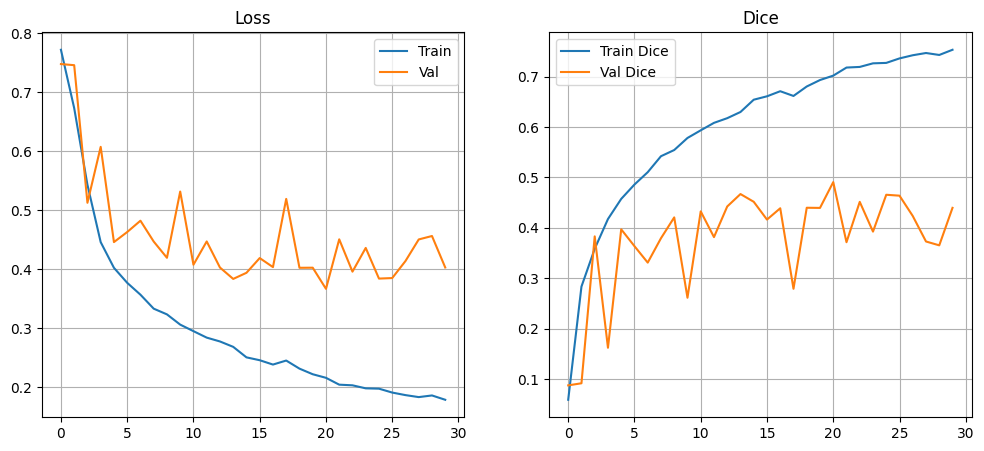

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(train_dices, label="Train Dice")
plt.plot(val_dices, label="Val Dice")
plt.title("Dice")
plt.legend()
plt.grid()

plt.show()

In [20]:
model = SimpleUNet().to(device)
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

x, y = next(iter(val_loader))
x_gpu = x.to(device)

with torch.no_grad():
    logits = model(x_gpu)
    probs = torch.sigmoid(logits)

print("Prob min/max:", probs.min().item(), probs.max().item())

Prob min/max: 7.334022712052191e-13 0.9999972581863403


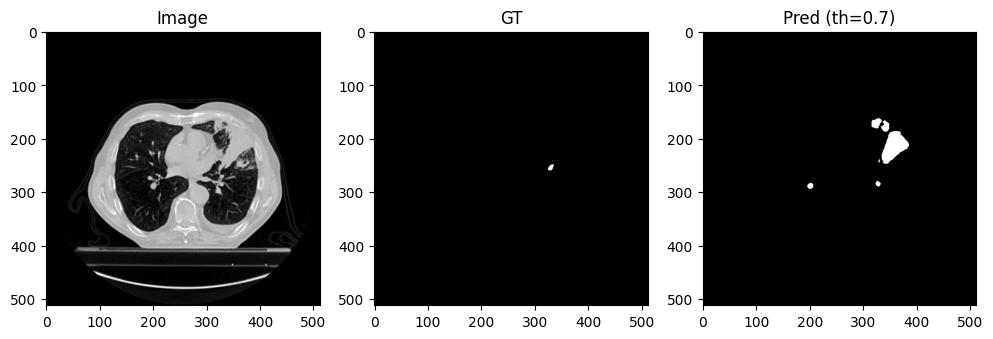

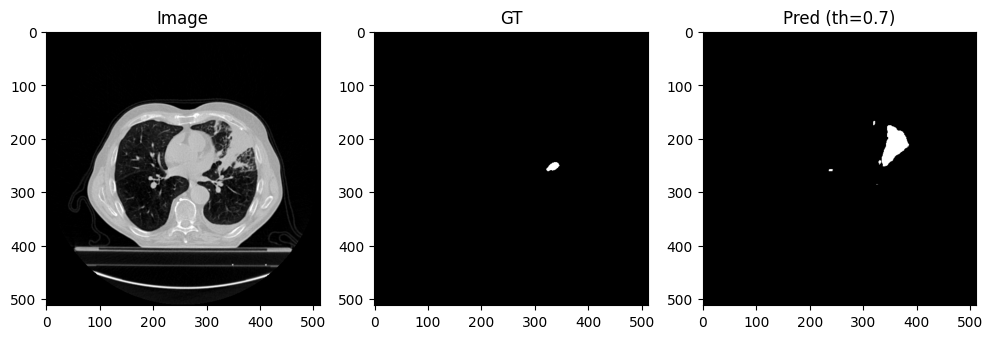

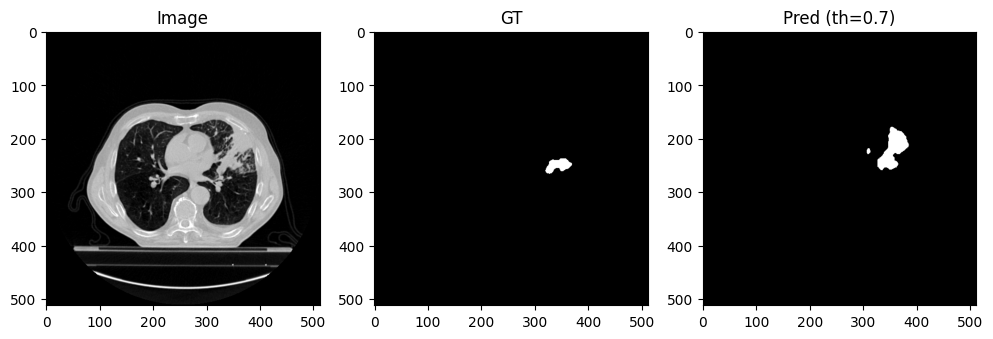

In [22]:
threshold = 0.7
preds = (probs > threshold).float().cpu()

for i in range(3):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(x[i,0], cmap="gray")
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(y[i,0], cmap="gray")
    plt.title("GT")

    plt.subplot(1,3,3)
    plt.imshow(preds[i,0], cmap="gray")
    plt.title(f"Pred (th={threshold})")

    plt.show()

In [23]:
import cv2

def clean_mask(mask):
    mask = mask.astype("uint8")
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

In [24]:
import scipy.ndimage as ndi

def largest_component(mask):
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = ndi.sum(mask, labeled, range(1, num+1))
    max_label = np.argmax(sizes) + 1
    return (labeled == max_label)